<a href="https://colab.research.google.com/github/MohamedSajidh11/northstar-database-analytics/blob/main/02_python_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.listdir('/content')

['.config', 'northstar_dataset.zip', 'sample_data']

In [2]:
from zipfile import ZipFile

with ZipFile('/content/northstar_dataset.zip', 'r') as zip:
    zip.extractall('/content/northstar_data')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:
import os

os.listdir('/content/northstar_data/northstar_dataset')

['README.txt',
 'data_dictionary.csv',
 'drivers.csv',
 'incidents.csv',
 'customers.csv',
 'orders.csv',
 'complaints.csv',
 'deliveries.csv',
 'hubs.csv',
 'vehicles.csv',
 'app_events.csv']

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

deliveries = pd.read_csv('/content/northstar_data/northstar_dataset/deliveries.csv')

complaints = pd.read_csv('/content/northstar_data/northstar_dataset/complaints.csv')

orders = pd.read_csv('/content/northstar_data/northstar_dataset/orders.csv')

customers = pd.read_csv('/content/northstar_data/northstar_dataset/customers.csv')

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [5]:
deliveries.columns

Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')

In [6]:
orders.columns

Index(['order_id', 'customer_id', 'service_type', 'order_created_at',
       'promised_window_hours', 'pickup_zone', 'dropoff_zone',
       'priority_level', 'order_value', 'booking_channel',
       'special_handling_flag'],
      dtype='object')

In [7]:
delivery_orders = pd.merge(
    deliveries,
    orders,
    on='order_id',
    how='inner'
)

delivery_orders.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,C0567,Business,2024-06-18 09:48:00,6,Central,CENTRAL,Medium,151.14,Web,0
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,C0480,Medical,2025-06-02 19:12:00,2,CENTRAL,NORTH,Medium,141.93,Web,0
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,C0616,Medical,2024-03-08 20:58:00,24,SOUTH,north,Low,11.11,App,0
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,C0276,Medical,2025-09-21 09:29:00,6,RiverSide,RiverSide,High,76.02,App,0


In [8]:
failure_data = delivery_orders[
    delivery_orders['delivery_status'] == 'Failed'
]

failure_data.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,C0567,Business,2024-06-18 09:48:00,6,Central,CENTRAL,Medium,151.14,Web,0
9,DL00010,O00836,D058,V057,H08,2025-09-22 19:09:00,2025-09-23 01:15:29.151459,Failed,9.85,1,...,C0186,Passenger,2025-09-22 16:20:00,6,SOUTH,north,Low,45.90,App,1
11,DL00012,O01207,D051,V017,H05,2024-12-26 19:41:00,2024-12-27 09:26:05.387672,Failed,16.96,3,...,C0197,Business,2024-12-26 18:58:00,6,CENTRAL,RiverSide,Medium,321.68,App,0
21,DL00022,O01027,D088,V011,H07,2025-08-24 00:21:00,2025-08-24 04:25:39.715444,Failed,15.81,0,...,C0492,Parcel,2025-08-23 21:51:00,4,EAST,Central,Medium,97.55,App,0
25,DL00026,O00906,D092,V055,H04,2025-02-04 11:16:00,2025-02-06 01:48:45.831712,Failed,14.27,2,...,C0480,Passenger,2025-02-04 09:04:00,24,WEST,RiverSide,High,133.71,App,0


In [9]:
failure_data['service_type'].value_counts()

,count
service_type,
Passenger,38
Retail,28
Business,25
Parcel,25
Medical,16


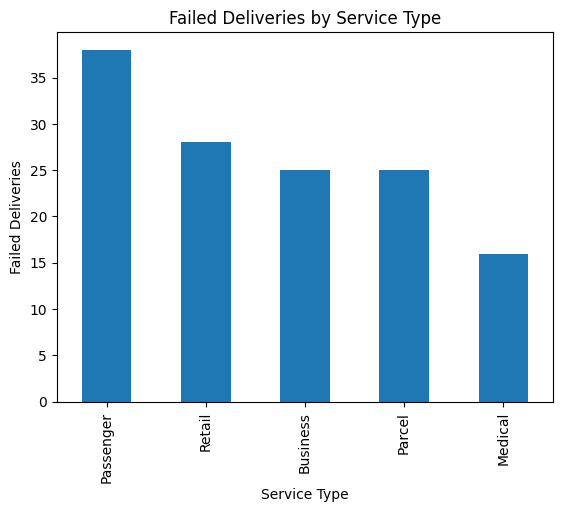

In [10]:
failure_data['service_type'].value_counts().plot(kind='bar')

plt.title("Failed Deliveries by Service Type")

plt.xlabel("Service Type")

plt.ylabel("Failed Deliveries")

plt.show()

## Service Failure Insight

The analysis indicates that certain service categories experience significantly higher delivery failure rates. This suggests that operational complexity, scheduling inefficiencies, or route conditions may differ across service types. High-failure services should be prioritised for operational review and process optimisation to reduce customer dissatisfaction and improve delivery reliability.

In [11]:
complaint_customers = pd.merge(
    complaints,
    customers,
    on='customer_id',
    how='inner'
)

complaint_customers.head()

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99,71,AIRPORT,Enterprise,2024-07-27 08:02:00,28.8,49.2,Phone,Dormant
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64,54,NORTH,Consumer,2024-06-03 02:11:00,71.1,32.0,App,Active
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41,20,north,Consumer,2024-11-15 02:13:00,NaN,60.5,App,Active
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44,44,North,Consumer,2024-02-12 04:44:00,65.8,81.4,Web,Active
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18,39,SOUTH,Consumer,2024-06-18 21:50:00,38.6,80.2,Web,Active


In [12]:
complaint_customers['complaint_type'].value_counts()

,count
complaint_type,
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


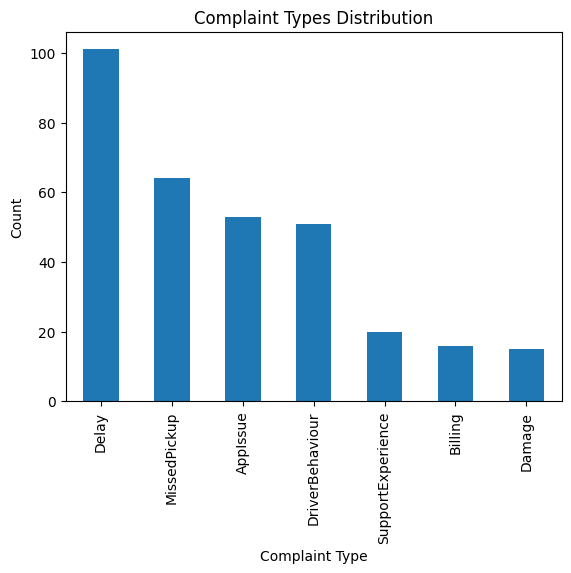

In [13]:
complaint_customers['complaint_type'].value_counts().plot(kind='bar')

plt.title("Complaint Types Distribution")

plt.xlabel("Complaint Type")

plt.ylabel("Count")

plt.show()

## Complaint Analysis Insight

The complaint analysis reveals recurring operational and customer service issues across multiple complaint categories. High complaint frequencies suggest inefficiencies in delivery operations, communication, or service coordination. These issues may contribute to reduced customer satisfaction, increased compensation costs, and reputational damage for the organisation.

In [14]:
complaint_customers.groupby('customer_type')['compensation_amount'].mean()

,compensation_amount
customer_type,
Consumer,20.623853
Enterprise,20.228077
SME,18.471277


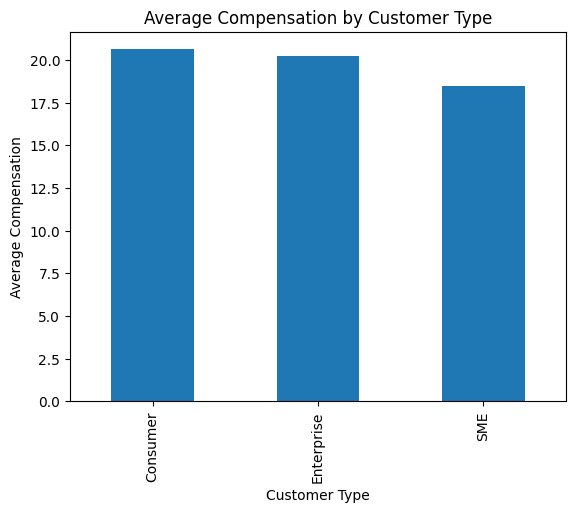

In [15]:
complaint_customers.groupby('customer_type')['compensation_amount'].mean().plot(kind='bar')

plt.title("Average Compensation by Customer Type")

plt.xlabel("Customer Type")

plt.ylabel("Average Compensation")

plt.show()